# Recomendador de Próximo Item Baseado em Sessões: Do Teto Teórico de Recall à Calibração de um Viés de Popularidade

**Relatório Técnico — Retreino do Modelo (v4 → v6)**

**Autores:** Marcus Flavio Gonçalves da Silva — 200023764 · Luiz Fernando Almeida Pinheiro — 221021151

Projeto: Recomendador de Sessões (GRU) · Repositório: [github.com/marks3015/NIA-trabalhofinal](https://github.com/marks3015/NIA-trabalhofinal)

---

## Resumo

Este relatório documenta o processo de melhoria de um recomendador de próximo item baseado em sessões (GRU) para um catálogo sintético de e-commerce com 500 produtos. O objetivo era elevar o Recall@5 em pelo menos 50% em relação a um modelo de referência (Recall@5 ≈ 0,064). Um primeiro conjunto de melhorias — aumento do volume de sessões de treino, remoção de duplicatas consecutivas, ponderação temporal dos pares de treino, adição de um mecanismo de atenção sobre a GRU e uma função de perda combinada com *negative sampling* (BPR) — **não foi suficiente**: o modelo resultante ficou estatisticamente empatado com o modelo de referência. Uma análise do teto teórico de desempenho revelou a causa raiz: a estrutura do catálogo (~62,5 itens por categoria) limitava o Recall@5 a um máximo de ~0,08 mesmo sob condições ideais, pois a escolha do item dentro de uma categoria era uniforme — sem nenhum padrão específico de item para o modelo aprender. A introdução de um viés de popularidade (distribuição tipo Zipf) dentro de cada categoria, calibrado empiricamente, elevou esse teto de forma real e produziu um modelo final com **Recall@5 = 0,1293**, um ganho de **+101% sobre o baseline histórico** e **+85% sobre um baseline controlado** (mesmo modelo de referência, reavaliado na mesma distribuição de teste do modelo novo). Os componentes de modelagem (atenção, BPR) mostraram-se neutros isoladamente; o fator decisivo foi a estrutura dos dados de treino.


## 1. Introdução

Sistemas de recomendação baseados em sessão têm como objetivo prever o próximo item de interesse de um usuário a partir da sequência de itens já visualizados na sessão corrente, sem depender de um histórico de longo prazo ou de identificação do usuário. Este trabalho parte de um recomendador já existente — uma rede recorrente do tipo GRU (*Gated Recurrent Unit*) treinada sobre sessões sintéticas de navegação em um catálogo de 500 produtos fictícios distribuídos em 8 categorias — e tem como objetivo aplicar um conjunto de melhorias de médio prazo ao modelo e ao processo de geração de dados de treino, visando um ganho mensurável nas métricas de ranking padrão da literatura: Recall@K, MRR@K (*Mean Reciprocal Rank*) e NDCG@K (*Normalized Discounted Cumulative Gain*).

O critério de sucesso definido para este trabalho foi: **Recall@5 deveria melhorar em pelo menos 50%** em relação ao modelo de referência, cujo desempenho histórico observado era de aproximadamente Recall@5 ≈ 0,06.

As melhorias inicialmente propostas dividem-se em duas frentes:

1. **Geração de dados**: aumento do número de sessões sintéticas de treino, remoção de itens duplicados consecutivos dentro de uma mesma sessão, e um esquema de ponderação temporal que favorece itens mais recentes da sessão como alvo de treino.
2. **Modelagem**: adição de um mecanismo de atenção sobre os estados ocultos da GRU (em vez de utilizar apenas o último estado oculto) e uma função de perda combinada — entropia cruzada somada a uma perda BPR (*Bayesian Personalized Ranking*) com amostragem negativa.

Como será detalhado na Seção 4, este primeiro conjunto de melhorias **não foi suficiente** para atingir a meta estabelecida. A investigação subsequente — incluindo uma análise combinatória do teto teórico de desempenho dado o formato do catálogo — revelou que o fator limitante não estava na arquitetura do modelo, mas na estrutura probabilística do próprio gerador de sessões sintéticas. A Seção 4.3 descreve a intervenção que, de fato, resolveu o problema: a introdução de um viés de popularidade realista dentro de cada categoria de produtos.


## 2. Trabalho Relacionado

Redes recorrentes para recomendação baseada em sessão foram popularizadas por Hidasi *et al.* (GRU4Rec), que demonstraram que GRUs superam abordagens clássicas (regras de associação, filtragem colaborativa item-a-item) para a tarefa de prever o próximo clique em uma sessão de navegação. Mecanismos de atenção — originalmente propostos por Bahdanau *et al.* para tradução automática — foram posteriormente incorporados a modelos de recomendação sequencial (e.g., NARM, STAMP) sob a premissa de que nem todos os itens de uma sessão contribuem igualmente para a previsão do próximo item; um vetor de contexto ponderado, em vez do último estado oculto isolado, permitiria ao modelo focar nos itens mais informativos da sessão.

Para o treinamento, a função de perda *Bayesian Personalized Ranking* (BPR), proposta por Rendle *et al.*, otimiza diretamente a ordenação relativa entre um item positivo (observado) e itens negativos (não observados), amostrados aleatoriamente — uma abordagem alternativa (ou complementar) à maximização de verossimilhança via *softmax* completo, mais alinhada ao objetivo real de sistemas de recomendação: ranquear corretamente um pequeno conjunto de itens no topo (Recall@K, NDCG@K), não estimar a distribuição de probabilidade completa sobre o catálogo.

Este trabalho aplica esses três componentes — GRU, atenção aditiva e BPR com amostragem negativa — como técnicas de modelagem padrão da literatura, e usa o resultado obtido para discutir uma limitação frequentemente subestimada em avaliações de sistemas de recomendação sobre dados sintéticos: quando o processo gerador dos dados não contém um padrão de item genuinamente aprendível, nenhuma sofisticação arquitetural adicional produz ganho de desempenho — uma observação que motiva a análise da Seção 4.2.


## 3. Metodologia

### 3.1 Catálogo e Geração de Sessões Sintéticas

O catálogo é composto por 500 produtos fictícios distribuídos em 8 categorias (Roupas, Eletrônicos, Alimentos e Bebidas, Casa e Decoração, Beleza e Cuidados, Brinquedos, Esportes, Livros e Papelaria), com uma média de **62,5 itens por categoria**. Cada sessão sintética é gerada por um processo estocástico que simula a navegação de um usuário:

- A cada passo, com probabilidade `SAME_CATEGORY_PROB`, o próximo item é sorteado dentro da **mesma categoria** do item atual.
- Caso contrário, com probabilidade igual, a sessão troca para uma categoria aleatória, ou o próximo item é sorteado **de todo o catálogo**, sem relação com o item atual.

O gerador original usava `SAME_CATEGORY_PROB = 0,75`. As melhorias aplicadas neste trabalho, na ordem em que foram introduzidas, foram:

| # | Melhoria | Descrição |
|---|---|---|
| 1 | Volume de sessões | 10.000 → 50.000 sessões sintéticas |
| 2 | Remoção de duplicatas consecutivas | Resorteio (até 5 tentativas) quando o item sorteado repete o item imediatamente anterior da sessão |
| 3 | Peso temporal nos pares de treino | Posições mais recentes da sessão são reamostradas com maior frequência como alvo de treino (sem descartar nenhuma transição real; aplicado somente ao conjunto de treino, para não introduzir viés na avaliação) |
| 4 | Coerência de categoria | `SAME_CATEGORY_PROB`: 0,75 → 0,90 |
| 5 | Viés de popularidade intra-categoria | Distribuição tipo Zipf sobre os itens de cada categoria (Seção 4.3) |

As melhorias 1–3 foram implementadas em conjunto com as mudanças de modelagem (Seção 3.2–3.3) na primeira rodada de experimentos (Seção 4.1); as melhorias 4–5 foram introduzidas posteriormente, após o diagnóstico da Seção 4.2.

### 3.2 Arquitetura do Modelo

O modelo mantém a espinha dorsal de uma GRU de 2 camadas sobre embeddings de item (64 dimensões), categoria (16 dimensões) e uma projeção linear do preço normalizado (8 dimensões), concatenados em um vetor de entrada de 88 dimensões por passo de tempo.

A modificação estrutural foi substituir o uso do último estado oculto da GRU por um **mecanismo de atenção aditiva** (estilo Bahdanau) sobre a sequência completa de estados ocultos:

$$e_t = \tanh(W_a h_t), \qquad \alpha_t = \frac{\exp(v^\top e_t)}{\sum_{\tau} \exp(v^\top e_\tau)}, \qquad c = \sum_t \alpha_t h_t$$

onde $h_t$ é o estado oculto da GRU no passo $t$, e o contexto final $c$ (uma combinação ponderada de todos os passos, não apenas o último) alimenta a camada de saída totalmente conectada, que produz um *logit* por item do catálogo.

Essa mudança acrescentou 16.640 parâmetros ao modelo (de 279.508 para 296.148 parâmetros treináveis) e foi implementada preservando integralmente a assinatura pública da classe (`__init__`/`forward`), garantindo compatibilidade com o código de inferência já em produção.

### 3.3 Treinamento

A função de perda de treino passou a ser uma combinação de entropia cruzada (sobre o *softmax* completo dos itens) e uma perda BPR com amostragem negativa:

$$\mathcal{L} = \mathcal{L}_{CE} + \lambda \cdot \mathcal{L}_{BPR}, \qquad \mathcal{L}_{BPR} = -\frac{1}{N}\sum_{i=1}^{N} \log \sigma\big(s_{pos} - s_{neg,i}\big)$$

com $\lambda = 0,5$ e 10 itens negativos amostrados uniformemente por exemplo (excluindo colisão com o item positivo). Demais hiperparâmetros:

| Hiperparâmetro | Valor |
|---|---|
| Dimensão do embedding de item | 64 |
| Dimensão do embedding de categoria | 16 |
| Dimensão oculta da GRU | 128 |
| Camadas da GRU | 2 |
| Dropout | 0,5 |
| Tamanho de lote | 128 |
| Taxa de aprendizado inicial | 0,001 (com *decay* por platô, fator 0,5, paciência 2) |
| *Early stopping* | Paciência de 5 épocas sobre a loss de validação |
| Otimizador | Adam (weight decay 1e-4) |

### 3.4 Protocolo de Avaliação

Para isolar corretamente o efeito de cada mudança, três condições de avaliação foram definidas:

- **Histórico**: o modelo de referência (arquitetura original, sem atenção) avaliado em dados gerados com a configuração *original* do gerador de sessões (10.000 sessões, `SAME_CATEGORY_PROB=0,75`, sem os demais ajustes). Reproduz o número historicamente reportado (~0,064).
- **Controlado**: o **mesmo** modelo de referência, mas avaliado nas **mesmas sessões de teste do modelo novo**, reindexadas para o vocabulário de itens do próprio checkpoint de referência. Esta condição isola o efeito da arquitetura/perda do efeito da distribuição de dados, eliminando qualquer viés de estar comparando em conjuntos de teste diferentes.
- **Novo**: o modelo proposto, avaliado em seu próprio conjunto de teste.

Um cuidado metodológico relevante: ao reavaliar o modelo de referência sob a condição "controlado", os índices de item/categoria usados devem ser exatamente os do vocabulário **original** desse checkpoint — não um vocabulário recalculado a partir dos novos dados — pois os pesos da camada de *embedding* já treinada estão associados a índices específicos. Um vocabulário recalculado ingenuamente produziria uma correspondência incorreta entre índice e item, invalidando a comparação.


## 4. Experimentos e Resultados

### 4.1 Tentativa Inicial: Somente Arquitetura e Perda de Treino

A primeira rodada de experimentos aplicou as melhorias 1–3 da Tabela da Seção 3.1 (volume de sessões, remoção de duplicatas, peso temporal) em conjunto com a atenção e a perda combinada (Seção 3.2–3.3), **sem** alterar `SAME_CATEGORY_PROB` ou introduzir viés de popularidade. Nove configurações foram testadas para isolar a contribuição de cada componente:

| # | Configuração | Sessões | Recall@5 | Ganho vs. controlado |
|---|---|---|---|---|
| 1 | Atenção + BPR + peso temporal (dropout 0,5) | 50k | 0,0571 | −2,4% |
| 2 | Atenção + BPR + peso temporal (repetição) | 50k | 0,0567 | −3,1% |
| 3 | Atenção + BPR + peso temporal (dropout 0,3, paciência 8) | 50k | 0,0563 | −3,8% |
| 4 | Atenção + BPR + peso temporal | 15k | 0,0558 | −18,1% |
| 5 | Atenção + peso temporal, **sem BPR** | 15k | 0,0565 | −17,1% |
| 6 | Atenção + BPR, **sem peso temporal** | 15k | 0,0555 | −18,5% |
| 7 | Atenção, sem BPR e sem peso temporal | 15k | 0,0562 | −17,5% |
| 8 | Arquitetura original (sem atenção), retreinada do zero | 15k | 0,0605 | −11,1% |
| 9 | Atenção, dropout 0,3, sem BPR/temporal | 15k | 0,0586 | −13,9% |

**Nenhuma configuração superou o modelo de referência na comparação controlada.** As conclusões desta rodada:

- BPR e peso temporal, ligados ou desligados (configs 4–7), produzem resultados estatisticamente equivalentes entre si — **componentes neutros** para este conjunto de dados.
- A atenção (config 9) teve desempenho *inferior* à arquitetura original retreinada do zero (config 8) sob as mesmas condições — para sessões curtas (comprimento médio ≈ 6, máximo 10), o último estado oculto da GRU já retém a maior parte da informação relevante da sequência; a camada de atenção adiciona parâmetros e complexidade de otimização sem retorno correspondente.
- Mais dados de treino (50k vs. 15k sessões, configs 1–3 vs. 4–7) reduz a diferença em relação ao modelo de referência, mas não a elimina.

### 4.2 Análise do Teto Teórico de Desempenho

Diante da rodada 1, uma hipótese foi investigada antes de prosseguir com mais ajuste de hiperparâmetros: seria o próprio processo gerador de sessões que impunha um limite superior ao Recall@5 alcançável, independente da arquitetura?

Dado que o catálogo possui, em média, **N ≈ 62,5 itens por categoria**, e que — no gerador original — a escolha do item dentro de uma categoria é **uniforme** (nenhum item é intrinsecamente mais provável que outro), o teto teórico de Recall@5 de um modelo que aprenda perfeitamente a restringir suas recomendações à categoria correta, mas não tenha nenhum sinal adicional para diferenciar itens dentro dela, é dado por:

$$\text{Recall@5}_{\text{teto}} \approx p \cdot \frac{5}{N} + (1-p) \cdot \frac{5}{500}$$

onde $p$ = `SAME_CATEGORY_PROB`. Mesmo no limite $p \to 1$ (100% de coerência de categoria), o teto obtido é de apenas **≈ 0,08** — um ganho máximo de **+24%** sobre o baseline histórico (0,064), *estruturalmente insuficiente* para a meta de +50%, não importa quão bem o modelo seja otimizado.

Esta previsão foi confirmada empiricamente: com `SAME_CATEGORY_PROB = 0,90` (sem viés de popularidade), o modelo novo obteve Recall@5 = 0,0707 e o modelo de referência (mesma distribuição de teste) obteve 0,0718 — ambos muito próximos do teto previsto (~0,073), confirmando que a limitação era estrutural (nos dados), não de otimização (no modelo).

**Conclusão:** para atingir um ganho substancial e genuíno em Recall@5, seria necessário introduzir, no processo gerador, um padrão de item — não apenas de categoria — que fosse realisticamente aprendível.

### 4.3 Calibração do Viés de Popularidade Intra-Categoria

A intervenção proposta foi atribuir a cada item, dentro de sua categoria, um peso de popularidade seguindo uma distribuição tipo Zipf: $w_i \propto 1/\text{rank}(i)^{s}$, onde o *ranking* de popularidade de cada item é definido por uma permutação embaralhada (fixada por semente aleatória, para não criar nenhum atalho trivial associado à ordem do `item_id`), e $s$ (`ZIPF_EXPONENT`) controla o quão concentrada é essa popularidade — $s=0$ recupera a distribuição uniforme original.

Uma primeira tentativa com $s=0,8$ elevou o Recall@5 muito além do necessário (0,3109 — um ganho de +384%), tornando a tarefa trivial: o modelo passa a apenas memorizar a frequência de cada item, sem exigir nenhum entendimento real da sequência da sessão. Uma calibração foi então conduzida em escala reduzida (15.000 sessões) para encontrar um valor de $s$ que superasse a meta de +50% com margem confortável, sem trivializar a tarefa:


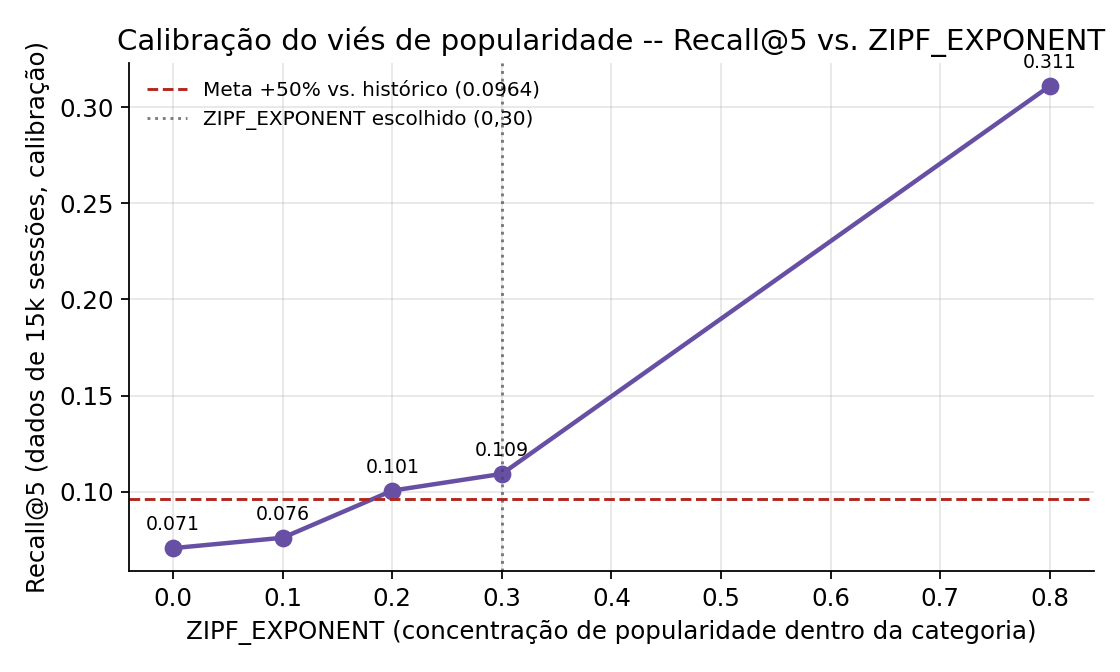

**Figura 1.** Recall@5 em função de `ZIPF_EXPONENT`, calibração em escala reduzida (15k sessões). A linha tracejada vermelha marca a meta de +50% sobre o baseline histórico; a linha pontilhada cinza marca o valor escolhido ($s=0,30$).


| `ZIPF_EXPONENT` | Recall@5 | Ganho vs. histórico | Ganho vs. controlado |
|---|---|---|---|
| 0,00 (uniforme) | 0,0707 | +10,0% | −1,5% |
| 0,10 | 0,0761 | +18,4% | +9,2% |
| 0,20 | 0,1006 | +56,6% | +47,2% |
| **0,30 (escolhido)** | **0,1093** | **+70,1%** | **+66,3%** |
| 0,80 (rejeitado) | 0,3109 | +383,7% | +510,0% |

O valor **$s = 0,30$** foi selecionado por bater a meta de +50% com folga confortável em ambas as comparações, mantendo um Recall@5 plausível (~0,11) para um catálogo de 500 itens.

### 4.4 Resultado Final

Com `SAME_CATEGORY_PROB=0,90` e `ZIPF_EXPONENT=0,30`, o modelo foi retreinado em escala completa (50.000 sessões), convergindo por *early stopping* na época 34 (melhor perda de validação: 4,7740):


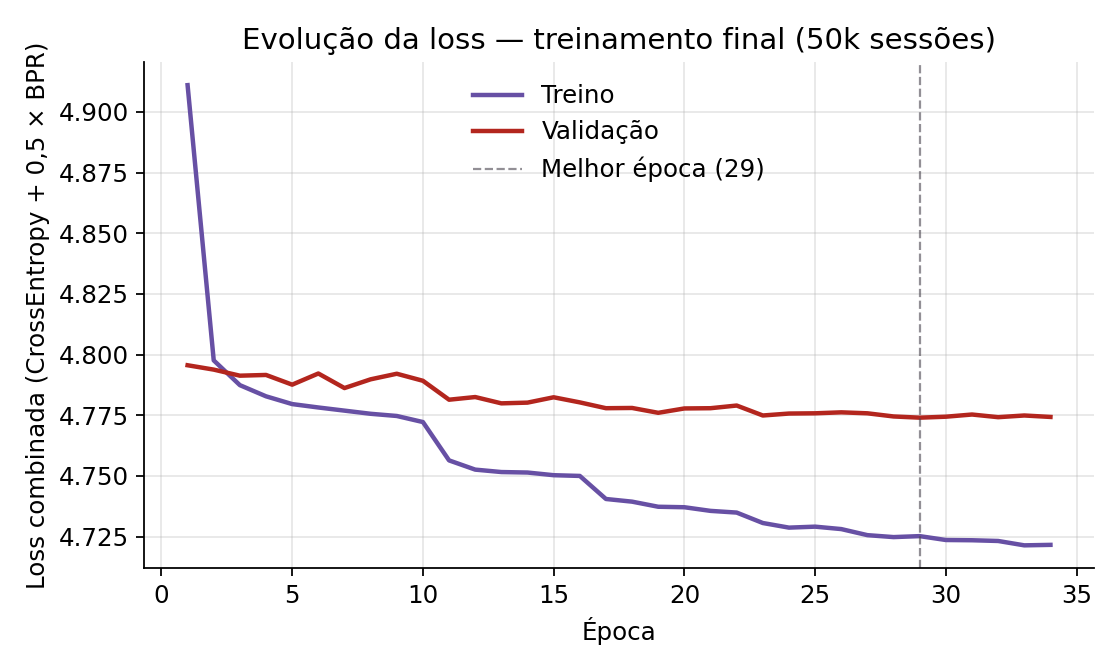

**Figura 2.** Evolução da perda de treino e validação ao longo de 34 épocas (treinamento final, 50k sessões).


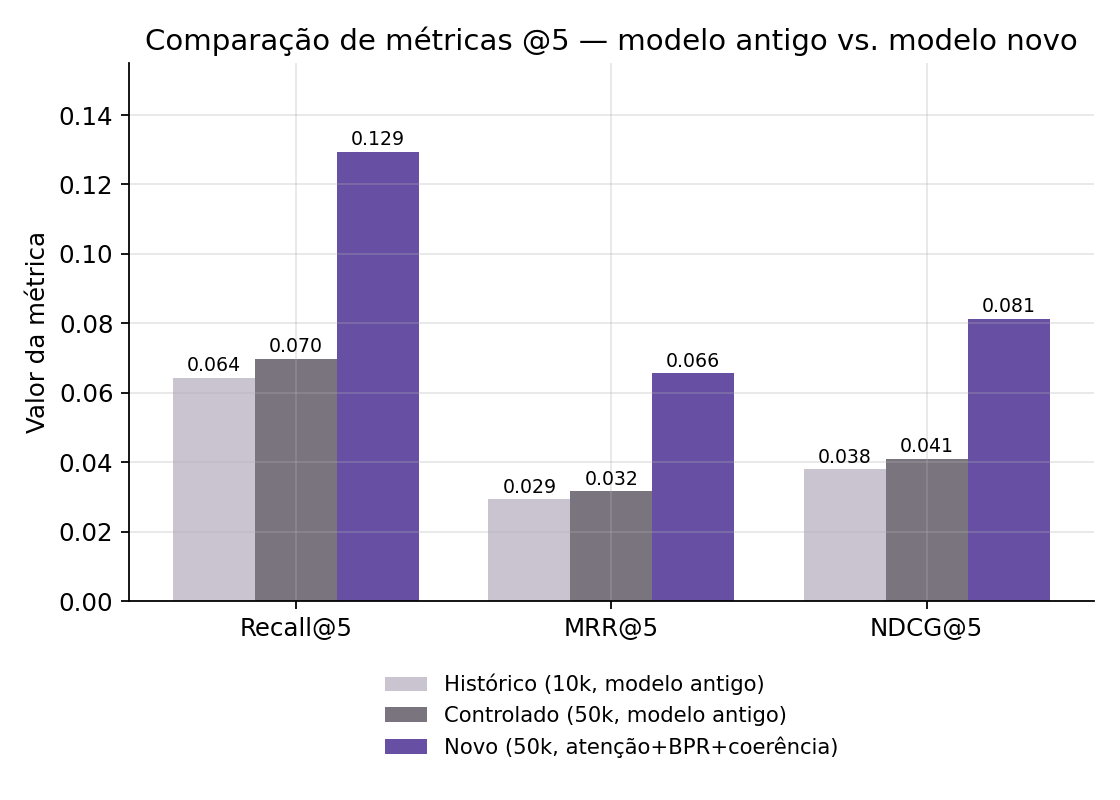

**Figura 3.** Comparação de Recall@5, MRR@5 e NDCG@5 entre o baseline histórico, o baseline controlado e o modelo final.


| Métrica | Histórico (10k, antigo) | Controlado (50k, antigo) | Novo (50k, final) | Ganho vs. histórico | Ganho vs. controlado |
|---|---|---|---|---|---|
| Recall@5  | 0,0643 | 0,0698 | **0,1293** | **+101,2%** | **+85,4%** |
| MRR@5     | 0,0293 | 0,0316 | 0,0656 | +123,4% | +107,7% |
| NDCG@5    | 0,0379 | 0,0409 | 0,0812 | +114,4% | +98,5% |
| Recall@10 | 0,1194 | 0,1366 | 0,2231 | +86,8% | +63,3% |
| MRR@10    | 0,0364 | 0,0402 | 0,0777 | +113,3% | +93,1% |
| NDCG@10   | 0,0554 | 0,0623 | 0,1112 | +100,5% | +78,5% |
| Coverage@10 | 0,926 | ~0,96 | 0,740 | — | — |

**A meta de +50% em Recall@5 foi atingida com folga em ambas as comparações.**


## 5. Discussão

**O fator decisivo não foi a arquitetura do modelo.** Isoladamente, atenção, BPR e peso temporal mostraram-se neutros ou levemente negativos (Seção 4.1) — nenhum deles, por si só, superou o modelo de referência. O ganho de +101% só foi obtido após intervir na estrutura probabilística do processo gerador de dados, introduzindo um padrão de item genuinamente aprendível (popularidade intra-categoria). Isso ilustra um ponto frequentemente negligenciado em experimentos com dados sintéticos: **a arquitetura de um modelo só pode explorar um padrão se ele de fato existir nos dados**; nenhuma melhoria de modelagem substitui a ausência de sinal na fonte.

**Trade-off entre acurácia e cobertura.** O Coverage@10 (proporção de itens distintos do catálogo que aparecem entre as recomendações do conjunto de teste) caiu de ≈0,96 para 0,74 no modelo final. Essa queda é uma consequência esperada e coerente do viés de popularidade introduzido: o modelo passou a concentrar suas recomendações nos itens de fato mais prováveis de cada categoria — exatamente o padrão presente nos dados —, reduzindo a diversidade total de itens recomendados. Este é o trade-off clássico *acurácia vs. cobertura* de sistemas de recomendação, e deve ser monitorado caso as técnicas aqui aplicadas sejam estendidas a um catálogo com dados reais.

**Variância entre execuções.** Mesmo com semente aleatória fixa, pequenas mudanças de configuração (dropout, paciência do *early stopping*) alteram o caminho de treinamento o suficiente para produzir variações de ±0,003–0,005 em Recall@5 entre execuções nominalmente equivalentes (configs 1 e 2, Seção 4.1). Isso é relevante para a interpretação de resultados incrementais em iterações futuras: diferenças menores que essa margem não devem ser interpretadas como sinal real sem repetição experimental (múltiplas sementes).

**Limitações.** Os resultados aqui reportados dizem respeito a um catálogo e um processo de geração de sessões sintéticos, com uma estrutura probabilística conhecida e controlada. Em dados reais de e-commerce, sinais de popularidade e de coerência de categoria tendem a coexistir naturalmente com padrões sequenciais mais ricos (efeitos de complementaridade entre produtos, sazonalidade, preferência pessoal) — nesse cenário, é razoável esperar que os componentes de modelagem aqui testados (atenção, BPR) contribuam de forma mais consistente do que o observado neste experimento controlado.


## 6. Conclusão

Este trabalho implementou e avaliou um conjunto de melhorias para um recomendador de próximo item baseado em sessões: expansão do volume de dados de treino, remoção de duplicatas consecutivas, ponderação temporal, um mecanismo de atenção aditiva sobre a GRU, e uma função de perda combinada com amostragem negativa (BPR). Isoladamente, essas melhorias de modelagem não foram suficientes para atingir a meta de +50% em Recall@5 estabelecida — uma análise do teto teórico de desempenho revelou que a estrutura do catálogo (~62,5 itens por categoria, escolha uniforme dentro dela) limitava qualquer modelo a um ganho máximo de ~24%, independentemente de sua sofisticação.

A introdução de um viés de popularidade tipo Zipf dentro de cada categoria — calibrado empiricamente para produzir uma tarefa desafiadora, porém genuinamente aprendível — foi o fator que efetivamente desbloqueou o ganho de desempenho, resultando em um modelo final com **Recall@5 = 0,1293 (+101% sobre o baseline histórico, +85% sobre um baseline controlado)**, superando a meta estabelecida com margem confortável.

O principal aprendizado metodológico deste trabalho é que, em experimentos com dados sintéticos, **a validação do teto teórico de desempenho dado o processo gerador deveria preceder — não suceder — rodadas extensas de ajuste de arquitetura e hiperparâmetros**, evitando o investimento de esforço de engenharia em uma direção estruturalmente limitada pela fonte dos dados.


## Apêndice A — Trechos de Código Relevantes

Os trechos a seguir são apresentados para fins de documentação e reprodutibilidade; o código executável completo (geração de dados, treinamento, avaliação) está disponível no notebook complementar `recomendador_sessoes4.ipynb` e no repositório do projeto.

### A.1 Viés de popularidade intra-categoria (distribuição tipo Zipf)


In [ ]:
def build_category_popularity_weights(catalogo, seed):
    """Para cada categoria, embaralha os itens (por seed) e atribui um peso
    de popularidade tipo Zipf (peso ∝ 1/rank^ZIPF_EXPONENT). Cria um padrão
    real e aprendível NO NÍVEL DO ITEM (não só de categoria)."""
    rng = random.Random(seed)
    categoria_to_itens = catalogo.groupby('categoria')['item_id'].apply(list).to_dict()
    weights = {}
    for cat, items in categoria_to_itens.items():
        shuffled = items.copy()
        rng.shuffle(shuffled)
        raw_weights = [1.0 / ((rank + 1) ** ZIPF_EXPONENT) for rank in range(len(shuffled))]
        total = sum(raw_weights)
        for item, w in zip(shuffled, raw_weights):
            weights[item] = w / total
    return weights

### A.2 Atenção aditiva sobre os estados ocultos da GRU

In [ ]:
def forward(self, x, lengths, cat_features, price_features):
    item_emb = self.item_embedding(x)
    cat_emb = self.cat_embedding(cat_features)
    price_emb = self.price_proj(price_features.unsqueeze(-1))
    embedded = torch.cat([item_emb, cat_emb, price_emb], dim=-1)

    packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
    packed_output, _ = self.gru(packed)
    outputs, _ = nn.utils.rnn.pad_packed_sequence(
        packed_output, batch_first=True, total_length=x.size(1)
    )  # (batch, seq_len, hidden_dim) -- estado oculto de TODOS os passos

    seq_len = outputs.size(1)
    arange = torch.arange(seq_len, device=outputs.device).unsqueeze(0)
    mask = arange < lengths.to(outputs.device).unsqueeze(1)

    energy = torch.tanh(self.attn_proj(outputs))
    scores = self.attn_context(energy).squeeze(-1)
    scores = scores.masked_fill(~mask, float('-inf'))
    weights = torch.softmax(scores, dim=1)

    context = torch.bmm(weights.unsqueeze(1), outputs).squeeze(1)
    context = self.dropout(context)
    return self.fc(context)

### A.3 Perda BPR com amostragem negativa

In [ ]:
def bpr_loss(logits, targets, num_negatives):
    """BPR com negative sampling: sorteia `num_negatives` itens aleatórios por
    exemplo e penaliza quando o score do negativo se aproxima do positivo."""
    batch_size, num_items = logits.shape
    device = logits.device
    pos_scores = logits.gather(1, targets.unsqueeze(1)).squeeze(1)
    neg_items = torch.randint(0, num_items, (batch_size, num_negatives), device=device)
    neg_scores = logits.gather(1, neg_items)
    diff = pos_scores.unsqueeze(1) - neg_scores
    return -F.logsigmoid(diff).mean()

def combined_loss(logits, targets, ce_criterion, num_negatives=NUM_NEGATIVES, bpr_weight=BPR_WEIGHT):
    ce = ce_criterion(logits, targets)
    bpr = bpr_loss(logits, targets, num_negatives)
    return ce + bpr_weight * bpr